In [46]:
import ase
from ase.io import read
from lammps_logfile import read_log

import regex as re
import os
import sys

from concurrent.futures import ThreadPoolExecutor, as_completed

import numpy as np

import matplotlib.pyplot as plt

from pprint import pprint

from tqdm import tqdm

In [47]:
# constants
kB_eV = 8.617333262e-5  # eV/K
au_to_kg = 9.10938356e-31
ev_to_j = 1.60218e-19
angstrom_per_m = 1e-10
ps_per_s = 1e-12
e = 1.60217663e-19

BACK_TO_METAL = 98.22695

METAL_TO_EV = au_to_kg * 10**4 / e

In [48]:
DIR1="OUTPUT"
DIR2="OUTPUT_LOCAL"

## Load thermo and traj

In [ ]:
def load_single_log_traj(log_file, log_dir, traj_dir, prefix="", start=0, end=-1):
    """
    Helper to load one log/traj pair.
    Returns a dict or None if missing.
    """
    pattern = re.compile(f"^{re.escape(prefix)}(\\d+)\\.log$", re.IGNORECASE)
    log_file_clean = log_file.strip()
    match = pattern.match(log_file_clean)
    if not match:
        return None
    number = match.group(1)
    traj_file = os.path.join(traj_dir, f"{prefix}{number}.traj")
    log_path = os.path.join(log_dir, log_file_clean)

    if not os.path.exists(traj_file):
        print(f"Warning: Trajectory file not found for {log_file_clean}")
        return None

    try:
        traj = read(traj_file, index=f'{start}_{end}')
    except Exception as e:
        print(f"Error reading trajectory {traj_file}: {e}")
        return None

    try:
        thermo = read_log(log_path)
        thermo=thermo[start:end]
    except Exception as e:
        print(f"Error reading thermo from {log_file_clean}: {e}")
        return None

    return {
        'number': number,
        'thermo': thermo,
        'traj': traj
    }

def load_thermo_and_traj_parallel(log_dir, traj_dir, prefix="", max_workers=16, NUM=-1, start, end):
    """
    Parallelized loading of LAMMPS log files and ASE trajectories.
    """
    print(__name__, log_dir, traj_dir, prefix, max_workers)
    files = os.listdir(log_dir)[:NUM]
    data = []

    max_workers = np.min((len(files), max_workers))

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = {executor.submit(load_single_log_traj, f, log_dir, traj_dir, prefix): f for f in files}
        for future in tqdm(as_completed(futures), total=len(futures)):
            result = future.result()
            if result is not None:
                data.append(result)

    # Sort by numeric order
    data.sort(key=lambda x: int(x['number']))
    return data

In [ ]:
data1 = load_thermo_and_traj_parallel(DIR1, DIR1+"/DUMP", prefix = "strainstress_", start=0, end=1000)
data2 = load_thermo_and_traj_parallel(DIR2, DIR2+"/DUMP", prefix="", NUM=10, start=0, end=1000)

__main__ OUTPUT OUTPUT/DUMP strainstress_ 16


100%|██████████| 20/20 [01:34<00:00,  4.71s/it]


__main__ OUTPUT_LOCAL OUTPUT_LOCAL/DUMP  16


100%|██████████| 10/10 [01:37<00:00,  9.79s/it]


In [51]:
print(data1[0]["thermo"].keys())
print(data1[0]["traj"])

Index(['Step', 'Temp', 'E_pair', 'E_mol', 'TotEng', 'Press', 'run_num', 'Lx',
       'Ly', 'Lz', 'Xy', 'Xz', 'Yz', 'v_exx', 'v_eyy', 'v_ezz', 'v_gxy',
       'v_gxz', 'v_gyz', 'c_press_compute[1]', 'c_press_compute[2]',
       'c_press_compute[3]', 'c_press_compute[4]', 'c_press_compute[5]',
       'c_press_compute[6]'],
      dtype='object')
[Atoms(symbols='C100', pbc=True, cell=[14.635982701613, 21.3027442648352, 100.0], momenta=..., calculator=SinglePointCalculator(...)), Atoms(symbols='C100', pbc=True, cell=[14.635982701613, 21.3027442648352, 100.0], momenta=..., calculator=SinglePointCalculator(...)), Atoms(symbols='C100', pbc=True, cell=[14.635982701613, 21.3027442648352, 100.0], momenta=..., calculator=SinglePointCalculator(...)), Atoms(symbols='C100', pbc=True, cell=[14.635982701613, 21.3027442648352, 100.0], momenta=..., calculator=SinglePointCalculator(...)), Atoms(symbols='C100', pbc=True, cell=[14.635982701613, 21.3027442648352, 100.0], momenta=..., calculator=SinglePointCa

In [52]:
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm

def pdd_traj(traj, max_workers=16):
    """Compute all distances for a trajectory using parallel execution."""
    def pdd_frame(frame):
        return frame.get_all_distances().flatten()

    data = []
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = {executor.submit(pdd_frame, frame): frame for frame in traj}
        for future in as_completed(futures):
            result = future.result()
            if result is not None:
                data.append(result)
    return np.array(data).flatten()


def pdd_data(data_list, max_workers=16, minidx=0, maxidx=-1):
    """Compute distances for a list of trajectory entries."""
    all_distances = []
    for entry in tqdm(data_list):
        traj = entry["traj"][minidx:maxidx+1]
        all_distances.append(pdd_traj(traj, max_workers=max_workers))
    return np.array(all_distances).flatten()

In [53]:
pdd1 = pdd_data(data1, max_workers=16, minidx=0, maxidx=999)
pdd2 = pdd_data(data2, max_workers=16, minidx=0, maxidx=999)

100%|██████████| 10/10 [00:14<00:00,  1.42s/it]


(0.0, 5.0)

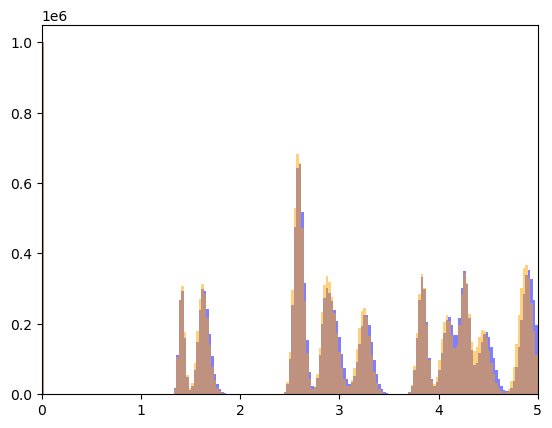

In [54]:
bins = np.linspace(0, 5, num=200)

plt.hist(pdd1, bins=bins, alpha=0.5, color = "blue");
plt.hist(pdd2, bins=bins, alpha=0.5, color="orange");

plt.xlim((0,5))

In [55]:
def correct_entry(entry, max_workers=16):
    def correct_frame(index, frame):
        frame.set_velocities(frame.get_velocities() * BACK_TO_METAL)
        return index, frame  # return the index with the frame

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = [executor.submit(correct_frame, i, frame) for i, frame in enumerate(entry['traj'])]
        for future in as_completed(futures):
            i, corrected_frame = future.result()
            if corrected_frame is not None:
                entry['traj'][i] = corrected_frame

    return entry

def correct_data(data, max_workers = 16):
    for i, entry in tqdm(enumerate(data), total = len(data)):
        data[i] = correct_entry(entry, max_workers = max_workers)

    return data

In [56]:
data1 = correct_data(data1)
data2 = correct_data(data2)

100%|██████████| 10/10 [00:09<00:00,  1.03it/s]


In [64]:
import numpy as np
from scipy.optimize import curve_fit

# Constants
kB = 1.380649e-23        # J/
au_to_kg = 1.66053906660e-27  # kg
METALTOJ = au_to_kg * 1e4
JTOMETAL = 1./METALTOJ


def mb_speed_distribution(v, T, mass_au):
    """
    v: speed in metal units (Å/ps)
    mass_au: atomic mass in amu
    T: temperature in K
    returns probability density in same units (Å/ps)
    """

    # Maxwell-Boltzmann prefactor in SI
    pref = 4 * np.pi * (mass_au / (2 * np.pi * kB * T * JTOMETAL))**1.5

    # exponent
    exponent = -0.5 * mass_au * v**2 / (kB * T * JTOMETAL)

    # return probability density in Å/ps units
    # multiply by conversion factor to go from per m/s to per Å/ps
    density = pref * v**2 * np.exp(exponent)

    return density


def fit_temperature_from_speeds(speeds, mass_au, bins=100):
    """
    speeds: array of velocities in metal units (Å/ps)
    mass_au: atomic mass in amu
    bins: histogram bins
    returns fitted temperature, histogram centers, histogram values
    """
    speeds = np.asarray(speeds).flatten()
    
    # histogram in metal units
    hist, edges = np.histogram(speeds, bins=bins, density=True)
    centers = 0.5 * (edges[:-1] + edges[1:])
    
    T0 = np.mean(0.5 * mass_au * speeds**2) * METALTOJ / (1.5 * kB)
    
    # fit function
    def fit_func(v, T):
        return mb_speed_distribution(v, T, mass_au)
    
    popt, _ = curve_fit(fit_func, centers, hist, p0=[T0])
    T_fit = popt[0]
    
    return T_fit, centers, hist

In [74]:
totvels1 = []
totvels2 = []

for i in range(10):

    traj1=data1[i]['traj'][:1000]
    for atoms1 in traj1:
        totvels1.append(np.linalg.norm(atoms1.get_velocities(), axis = -1))

    traj2=data2[i]['traj'][:1000]
    for atoms2 in traj2:
        totvels2.append(np.linalg.norm(atoms2.get_velocities(), axis = -1)) 

totvels1 = np.vstack(totvels1)
totvels2 = np.vstack(totvels2)

T1, centers1, hist1 = fit_temperature_from_speeds(totvels1, 12.011, bins=100)
T2, centers2, hist2 = fit_temperature_from_speeds(totvels2, 12.011, bins=100)


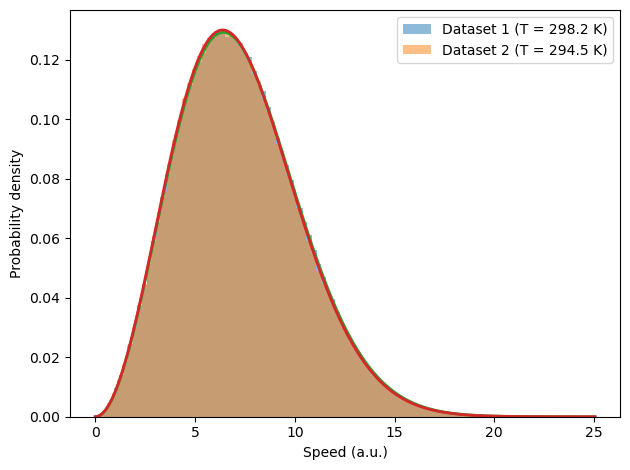

In [80]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

# Histogram dataset 1
ax.hist(
    totvels1.flatten(),
    bins=100,
    density=True,
    alpha=0.5,
    label=f"Dataset 1 (T = {T1:.1f} K)"
)

# Histogram dataset 2
ax.hist(
    totvels2.flatten(),
    bins=100,
    density=True,
    alpha=0.5,
    label=f"Dataset 2 (T = {T2:.1f} K)"
)

# Velocity grid for smooth curves
vmax = max(np.max(totvels1), np.max(totvels2))
v = np.linspace(0, vmax, 500)

# Plot fitted Maxwell–Boltzmann curves
ax.plot(v, mb_speed_distribution(v, T1, 12.011), linewidth=2)
ax.plot(v, mb_speed_distribution(v, T2, 12.011), linewidth=2)

ax.set_xlabel("Speed (a.u.)")
ax.set_ylabel("Probability density")
ax.legend()
plt.tight_layout()
plt.show()